In [88]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

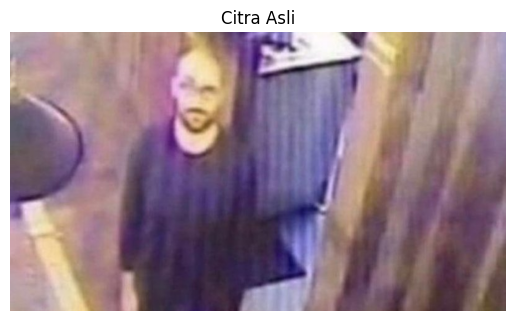

In [89]:
backup = plt.imread('backup.jpg')

plt.imshow(backup)
plt.title('Citra Asli')
plt.axis('off')
plt.show()

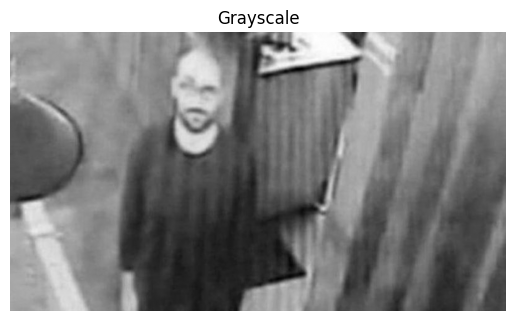

In [90]:
backup_gray = cv2.cvtColor(backup, cv2.COLOR_RGB2GRAY)

plt.imshow(backup_gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')
plt.show()

In [91]:
kernel_size = 3
pad = kernel_size // 2

padding = np.pad(backup_gray, pad_width=pad, mode='edge')

smooth = np.zeros_like(backup_gray)

for i in range(backup_gray.shape[0]):
    for j in range(backup_gray.shape[1]):

        area = padding[
            i:i+kernel_size,
            j:j+kernel_size
        ]

        mean = np.mean(area)

        smooth[i, j] = mean

In [92]:
kernel_sharp = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

padding_sharp = np.pad(backup_gray, pad_width=1, mode='edge')

sharp = np.zeros_like(backup_gray)

for i in range(backup_gray.shape[0]):
    for j in range(backup_gray.shape[1]):

        area = padding_sharp[
            i:i+3,
            j:j+3
        ]

        total = np.sum(area * kernel_sharp)

        if total < 0:
            total = 0

        if total > 255:
            total = 255

        sharp[i, j] = total

In [93]:
padding_combo = np.pad(smooth, pad_width=1, mode='edge')

smooth_sharp = np.zeros_like(smooth)

for i in range(smooth.shape[0]):
    for j in range(smooth.shape[1]):

        area = padding_combo[
            i:i+3,
            j:j+3
        ]

        total = np.sum(area * kernel_sharp)

        if total < 0:
            total = 0

        if total > 255:
            total = 255

        smooth_sharp[i, j] = total

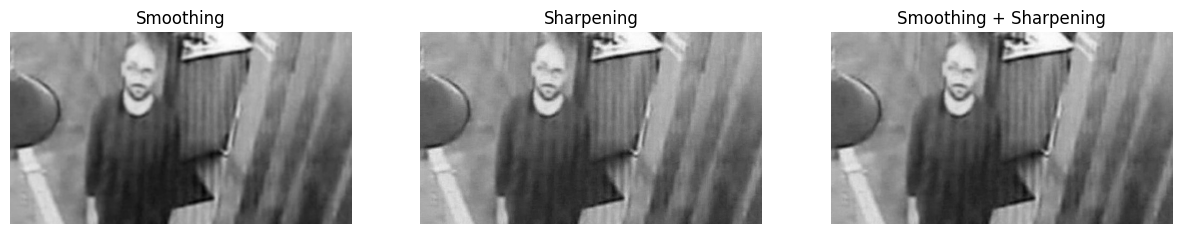

In [94]:
plt.figure(figsize=(15,5))

plt.subplot(1, 3, 1)
plt.imshow(smooth, cmap='gray')
plt.title('Smoothing')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sharp, cmap='gray')
plt.title('Sharpening')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(smooth_sharp, cmap='gray')
plt.title('Smoothing + Sharpening')
plt.axis('off')

plt.show()

ANALISIS

Smoothing untuk mengurangi noise, citra jadi lebih halus.Kalau sharpening untuk memperjelas detail tepi objek. Kalau digabung smoothing dan sharpening citra nya jadi bersih gak ada noise tapi detail citranya tetap ada.

Mean menghitung rata-rata nilai piksel jadi citra lebih halus, tapi agak blur. Median mengambil nilai tengah dari piksel jadi lebih hilangin noise tapi detailnya masih aman gitu. Kalau modus mengambil nilai yang paling sering muncul.

In [95]:
def edge_detection(gx, gy):

    total = np.sqrt(
        (gx ** 2) + (gy ** 2)
    )

    total = (
        total / np.max(total)
    ) * 255

    total = total.astype(np.uint8)

    return total

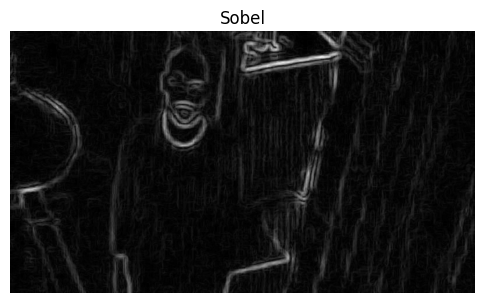

In [96]:
kernel_sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

kernel_sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

padding_sobel = np.pad(
    backup_gray,
    pad_width=1,
    mode='edge'
)

gx_sobel = np.zeros(
    backup_gray.shape,
    dtype=float
)

gy_sobel = np.zeros(
    backup_gray.shape,
    dtype=float
)

for i in range(backup_gray.shape[0]):
    for j in range(backup_gray.shape[1]):

        area = padding_sobel[
            i:i+3,
            j:j+3
        ]

        gx_sobel[i, j] = np.sum(
            area * kernel_sobel_x
        )

        gy_sobel[i, j] = np.sum(
            area * kernel_sobel_y
        )

sobel = edge_detection(
    gx_sobel,
    gy_sobel
)

plt.figure(figsize=(6,6))
plt.imshow(sobel, cmap='gray')
plt.title('Sobel')
plt.axis('off')
plt.show()

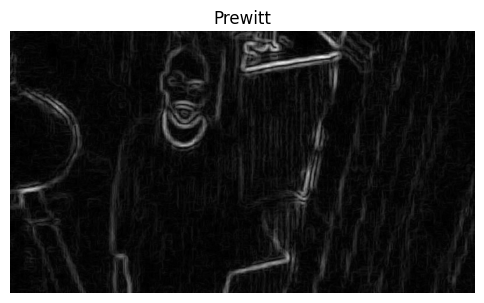

In [97]:
kernel_prewitt_x = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

kernel_prewitt_y = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
])

prewitt = np.zeros_like(backup_gray)

for i in range(backup_gray.shape[0]):
    for j in range(backup_gray.shape[1]):

        area = padding_sobel[
            i:i+3,
            j:j+3
        ]

        gx = np.sum(area * kernel_prewitt_x)

        gy = np.sum(area * kernel_prewitt_y)

        total = np.sqrt((gx ** 2) + (gy ** 2))

        if total > 255:
            total = 255

        prewitt[i, j] = total

plt.figure(figsize=(6,6))
plt.imshow(prewitt, cmap='gray')
plt.title('Prewitt')
plt.axis('off')
plt.show()

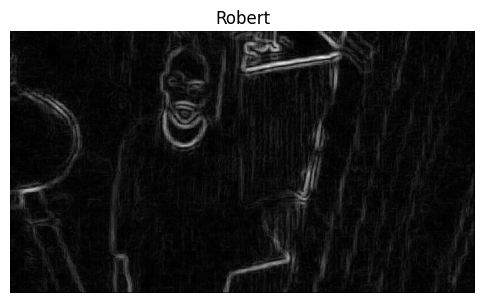

In [98]:
kernel_robert_x = np.array([
    [1, 0],
    [0,-1]
])

kernel_robert_y = np.array([
    [0, 1],
    [-1,0]
])

padding_robert = np.pad(backup_gray, pad_width=1, mode='edge')

robert = np.zeros_like(backup_gray)

for i in range(backup_gray.shape[0]-1):
    for j in range(backup_gray.shape[1]-1):

        area = padding_robert[
            i:i+2,
            j:j+2
        ]

        gx = np.sum(area * kernel_robert_x)

        gy = np.sum(area * kernel_robert_y)

        total = np.sqrt((gx ** 2) + (gy ** 2))

        if total > 255:
            total = 255

        robert[i, j] = total

plt.figure(figsize=(6,6))
plt.imshow(robert, cmap='gray')
plt.title('Robert')
plt.axis('off')
plt.show()

In [99]:
sobel_prewitt = sobel + prewitt
sobel_robert = sobel + robert
prewitt_robert = prewitt + robert
soprero = (sobel + prewitt + robert)

sobel_prewitt = (sobel_prewitt / np.max(sobel_prewitt)) * 255

sobel_robert = (sobel_robert / np.max(sobel_robert)) * 255

prewitt_robert = (prewitt_robert / np.max(prewitt_robert)) * 255

soprero = (soprero /np.max(soprero)) * 255

sobel_prewitt = sobel_prewitt.astype(np.uint8)
sobel_robert = sobel_robert.astype(np.uint8)
prewitt_robert = prewitt_robert.astype(np.uint8)
soprero = soprero.astype(np.uint8)

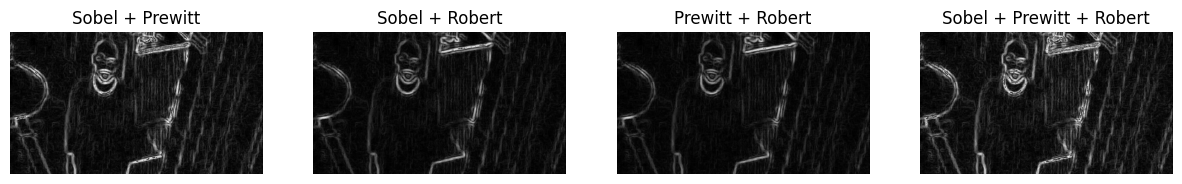

In [100]:
plt.figure(figsize=(15,5))

plt.subplot(1, 4, 1)
plt.imshow(sobel_prewitt, cmap='gray')
plt.title('Sobel + Prewitt')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(sobel_robert, cmap='gray')
plt.title('Sobel + Robert')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(prewitt_robert, cmap='gray')
plt.title('Prewitt + Robert')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(soprero, cmap='gray')
plt.title('Sobel + Prewitt + Robert')
plt.axis('off')

plt.show()

ANALISIS

Operator Sobel untuk mendeteksi tepi lihat perubahan intensitas horizontal dan vertikal. Operator Prewitt mirip sama sobel tapi dia 1, kan sobel 2 (maaf mba saya bingung jelasinnya gimana, maksudnya kalau sobel kan gx sama gy nya itu ada -1, 0, 1, -2, 2 nah kalau prewitt itu -1, 0, 1 aja, kernel nya sama 3x3). Operator Robert kernelnya 2x2.

Gabungan Sobel dan Prewitt tepinya lebih jelas karrna deteksi horizontal dan vertikal. Gabungan Sobel dan Robert detail tepinya tajam. Gabungan Prewitt dan Robert detail tepinya halus. Gabungan ketiganya keren.

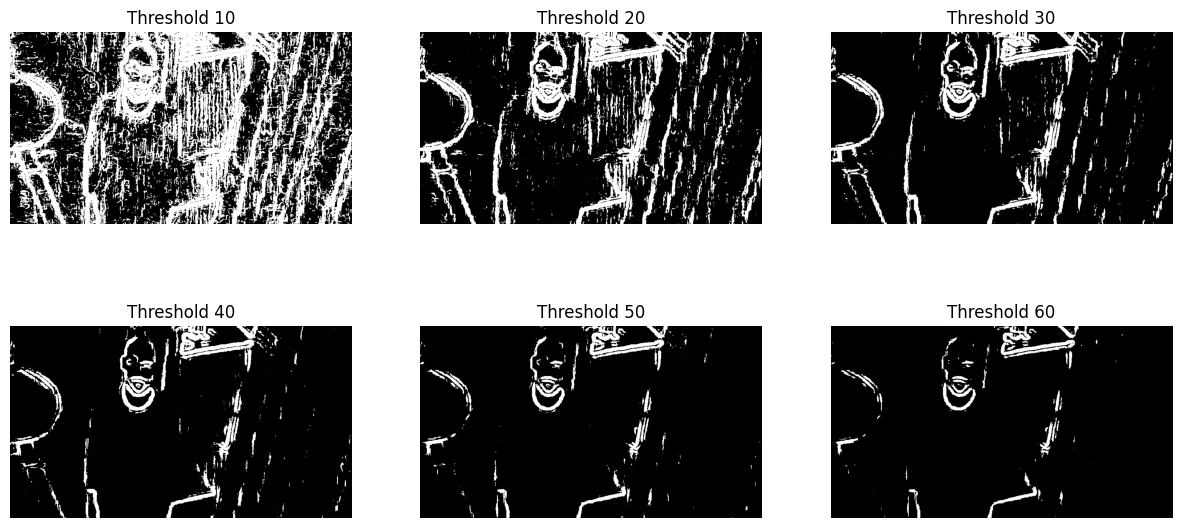

In [101]:
threshold_10 = np.zeros_like(sobel)
threshold_20 = np.zeros_like(sobel)
threshold_30 = np.zeros_like(sobel)
threshold_40 = np.zeros_like(sobel)
threshold_50 = np.zeros_like(sobel)
threshold_60 = np.zeros_like(sobel)

for i in range(sobel.shape[0]):
    for j in range(sobel.shape[1]):

        if sobel[i, j] > 10:
            threshold_10[i, j] = 255

        if sobel[i, j] > 20:
            threshold_20[i, j] = 255

        if sobel[i, j] > 30:
            threshold_30[i, j] = 255

        if sobel[i, j] > 40:
            threshold_40[i, j] = 255

        if sobel[i, j] > 50:
            threshold_50[i, j] = 255

        if sobel[i, j] > 60:
            threshold_60[i, j] = 255

plt.figure(figsize=(15,7))

plt.subplot(2, 3, 1)
plt.imshow(threshold_10, cmap='gray')
plt.title('Threshold 10')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(threshold_20, cmap='gray')
plt.title('Threshold 20')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(threshold_30, cmap='gray')
plt.title('Threshold 30')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(threshold_40, cmap='gray')
plt.title('Threshold 40')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(threshold_50, cmap='gray')
plt.title('Threshold 50')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(threshold_60, cmap='gray')
plt.title('Threshold 60')
plt.axis('off')

plt.show()

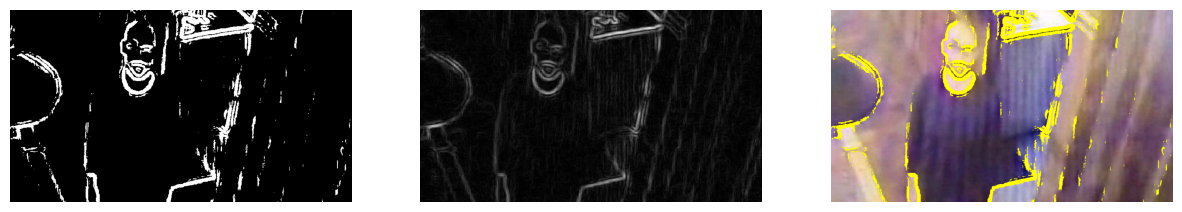

In [102]:
mask = np.zeros_like(sobel)

for i in range(sobel.shape[0]):
    for j in range(sobel.shape[1]):

        if sobel[i, j] > 40:
            mask[i, j] = 255

highlight = backup.copy()

for i in range(mask.shape[0]):
    for j in range(mask.shape[1]):

        if mask[i, j] == 255:

            highlight[i, j, 0] = 255
            highlight[i, j, 1] = 255
            highlight[i, j, 2] = 0

plt.figure(figsize=(15,5))

plt.subplot(1, 3, 1)
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sobel, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(highlight)
plt.axis('off')

plt.show()

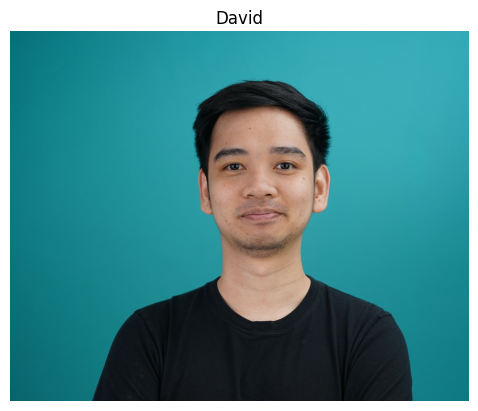

In [103]:
david = plt.imread('david.jpg')

plt.imshow(david)
plt.title('David')
plt.axis('off')
plt.show()

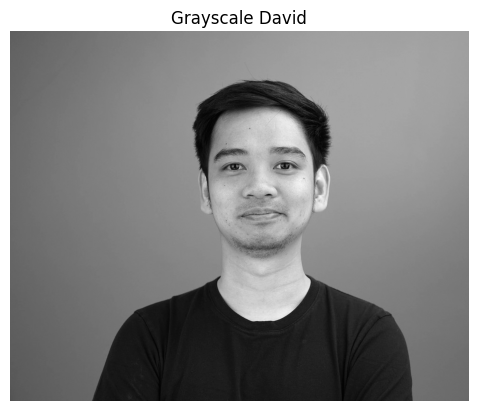

In [104]:
david_gray = cv2.cvtColor(david, cv2.COLOR_RGB2GRAY)

plt.imshow(david_gray, cmap='gray')
plt.title('Grayscale David')
plt.axis('off')
plt.show()

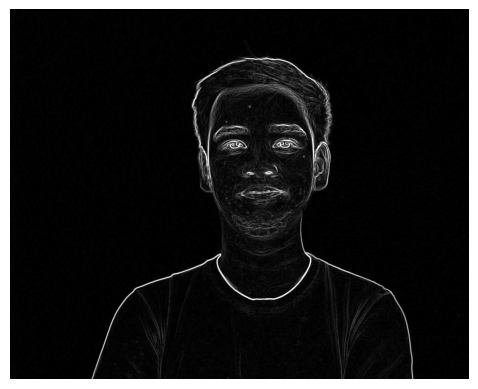

In [109]:
kernel_size = 3
pad = kernel_size // 2

padding_david = np.pad(david_gray, pad_width=pad, mode='edge')

david_smooth = np.zeros_like(david_gray)

for i in range(david_gray.shape[0]):
    for j in range(david_gray.shape[1]):

        area = padding_david[
            i:i+kernel_size,
            j:j+kernel_size
        ]

        median = np.median(area)

        david_smooth[i, j] = median

padding_sobel = np.pad(david_smooth, pad_width=1, mode='edge')

tepi_david = np.zeros_like(david_smooth)

for i in range(david_smooth.shape[0]):
    for j in range(david_smooth.shape[1]):

        area = padding_sobel[
            i:i+3,
            j:j+3
        ]

        gx = np.sum(area * kernel_sobel_x)

        gy = np.sum(area * kernel_sobel_y)

        total = np.sqrt((gx ** 2) + (gy ** 2))

        if total > 255:
            total = 255

        tepi_david[i, j] = total

plt.imshow(tepi_david, cmap='gray')
plt.axis('off')
plt.show()